# Grad-CAM — Análisis de Explicabilidad

**Objetivo:** Visualizar qué zonas del documento activaron la clasificación auténtico/falsificado usando tres variantes de Grad-CAM.

| Método | Descripción |
|--------|-------------|
| **GradCAM** | Clásico — gradientes de la clase objetivo respecto a la última capa conv |
| **GradCAM++** | Mejor localización para objetos pequeños (sellos, hologramas) |
| **EigenCAM** | Sin labels explícitos — más rápido, útil para inferencia en lote |

**6 casos documentados:**
1. Documento auténtico → Grad-CAM apunta a zona de texto principal
2. Falsificación por `text_blur` → apunta a zona blureada
3. Falsificación por `color_shift` → apunta al sello alterado
4. Falsificación por `splicing` → apunta a zona copiada
5. Falsificación por `hologram_noise` → apunta al holograma
6. Comparativa de los 3 métodos sobre el mismo documento

In [1]:
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.insert(0, str(Path.cwd().parent))

from src.data.augmentation import ForgeryConfig, ForgeryType, SyntheticForgeryGenerator
from src.explainability.gradcam import GradCAMExplainer
from src.explainability.visualizer import (
    cam_to_heatmap,
    most_activated_region,
    overlay_heatmap,
)
from src.models.classifier import DocumentClassifier
from src.preprocessing.pipeline import DocumentPreprocessor, PreprocessorConfig

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 10

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
CKPT = Path.cwd().parent / "models" / "saved" / "efficientnet_b0_best.pt"
GRADCAM_DIR = Path.cwd().parent / "reports" / "figures" / "gradcam_samples"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
print(f"Checkpoint: {CKPT} ({CKPT.stat().st_size / 1024:.0f} KB)")

Device  : mps
Checkpoint: /Users/julio/Desktop/document_authentication/models/saved/efficientnet_b0_best.pt (17235 KB)


In [2]:
# Cargar modelo y crear explainer
model = DocumentClassifier.load(CKPT, device=DEVICE)
explainer = GradCAMExplainer(model)

# Preprocesador: sin normalizar para visualización, con normalizar para inferencia
proc_vis = DocumentPreprocessor(PreprocessorConfig(perspective=False, normalize=False))
proc_norm = DocumentPreprocessor(PreprocessorConfig(perspective=False, normalize=True))

# Generador de falsificaciones
gen = SyntheticForgeryGenerator(seed=42)

# Cargar imágenes auténticas de muestra
SAMPLES_DIR = Path.cwd().parent / "data" / "samples"
authentic_imgs = [
    np.array(Image.open(p).convert("RGB"))
    for p in sorted((SAMPLES_DIR / "authentic").glob("*.png"))[:5]
]
print(f"Imágenes auténticas cargadas: {len(authentic_imgs)}")


def to_tensor(img_rgb: np.ndarray) -> torch.Tensor:
    """Preprocesar imagen RGB uint8 → tensor normalizado para el modelo."""
    processed = proc_norm.process(img_rgb)
    return torch.from_numpy(processed.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)


def to_vis(img_rgb: np.ndarray) -> np.ndarray:
    """Preprocesar imagen RGB uint8 → uint8 224×224 para visualización."""
    return proc_vis.process(img_rgb)

Imágenes auténticas cargadas: 5


## Caso 1: Documento auténtico

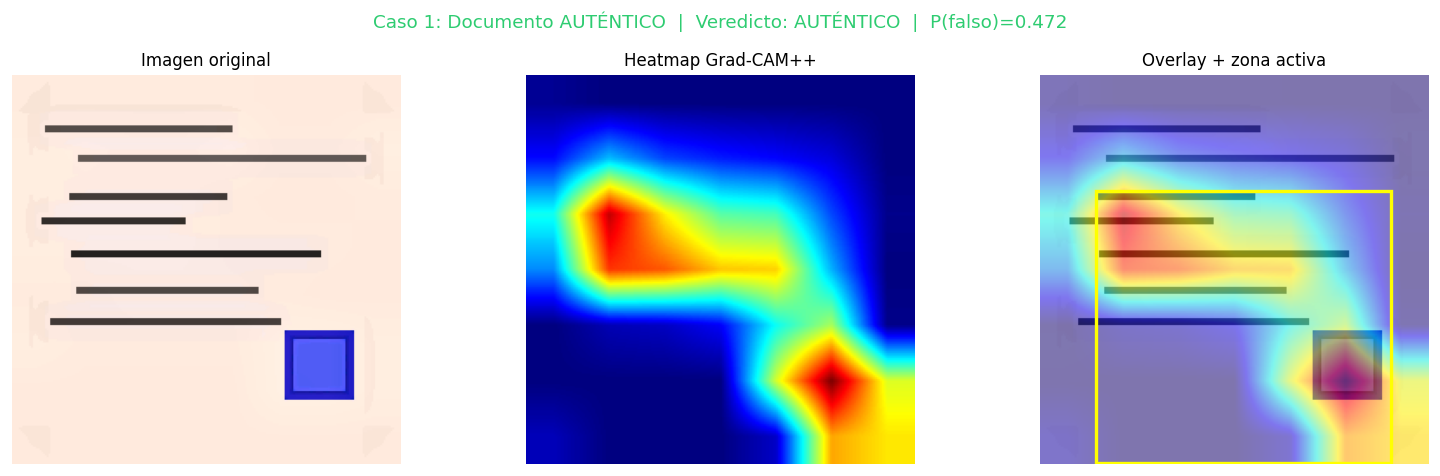

P(falsificado) = 0.4721  →  AUTÉNTICO
Zona más activa: x=[32,202] y=[66,223]
Activación media en región: 0.759


In [3]:
base_img = authentic_imgs[0]
tensor = to_tensor(base_img)
vis_img = to_vis(base_img)

cam, prob = explainer.explain(tensor, method="gradcam++")
overlay = overlay_heatmap(vis_img, cam)
region = most_activated_region(cam)

verdict = "FALSIFICADO" if prob >= 0.5 else "AUTÉNTICO"
color = "#e74c3c" if prob >= 0.5 else "#2ecc71"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(vis_img)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(cam_to_heatmap(cam))
axes[1].set_title("Heatmap Grad-CAM++")
axes[1].axis("off")

axes[2].imshow(overlay)
rect = mpatches.Rectangle(
    (region["x0"], region["y0"]),
    region["x1"] - region["x0"],
    region["y1"] - region["y0"],
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
axes[2].add_patch(rect)
axes[2].set_title("Overlay + zona activa")
axes[2].axis("off")

plt.suptitle(
    f"Caso 1: Documento AUTÉNTICO  |  Veredicto: {verdict}  |  P(falso)={prob:.3f}",
    fontsize=11,
    color=color,
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso1_autentico.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"P(falsificado) = {prob:.4f}  →  {verdict}")
print(f"Zona más activa: x=[{region['x0']},{region['x1']}] y=[{region['y0']},{region['y1']}]")
print(f"Activación media en región: {region['mean_activation']:.3f}")

## Caso 2: Falsificación por text_blur

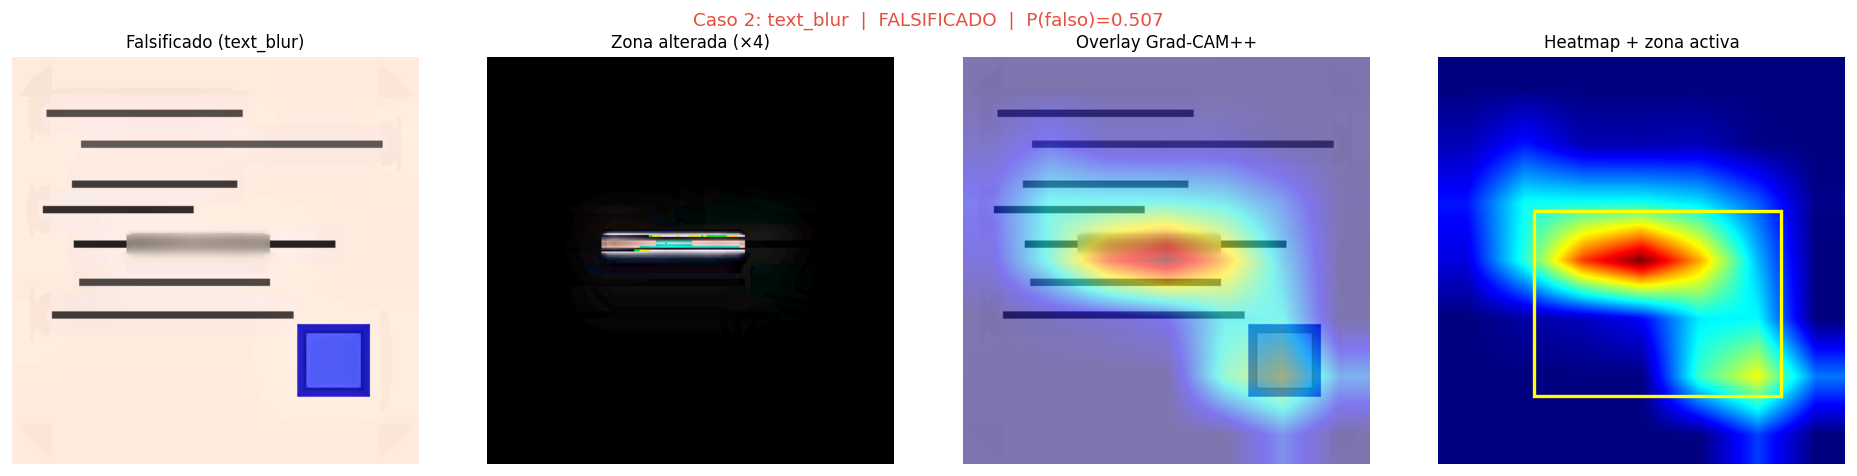

P(falsificado) = 0.5075  →  FALSIFICADO


In [4]:
config_blur = ForgeryConfig(forgery_type=ForgeryType.TEXT_BLUR, intensity="strong", seed=42)
forged_blur = gen.apply(base_img, config_blur)

tensor_blur = to_tensor(forged_blur)
vis_blur = to_vis(forged_blur)
cam_blur, prob_blur = explainer.explain(tensor_blur, method="gradcam++")
overlay_blur = overlay_heatmap(vis_blur, cam_blur)
region_blur = most_activated_region(cam_blur)

# Diferencia pixel-level para comparar con zona activada
diff = np.abs(to_vis(base_img).astype(np.int16) - vis_blur.astype(np.int16)).astype(np.uint8)

verdict = "FALSIFICADO" if prob_blur >= 0.5 else "AUTÉNTICO"
color = "#e74c3c" if prob_blur >= 0.5 else "#2ecc71"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(vis_blur)
axes[0].set_title("Falsificado (text_blur)")
axes[0].axis("off")

axes[1].imshow(np.clip(diff * 4, 0, 255), cmap="hot")
axes[1].set_title("Zona alterada (×4)")
axes[1].axis("off")

axes[2].imshow(overlay_blur)
axes[2].set_title("Overlay Grad-CAM++")
axes[2].axis("off")

axes[3].imshow(cam_to_heatmap(cam_blur))
rect = mpatches.Rectangle(
    (region_blur["x0"], region_blur["y0"]),
    region_blur["x1"] - region_blur["x0"],
    region_blur["y1"] - region_blur["y0"],
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
axes[3].add_patch(rect)
axes[3].set_title("Heatmap + zona activa")
axes[3].axis("off")

plt.suptitle(
    f"Caso 2: text_blur  |  {verdict}  |  P(falso)={prob_blur:.3f}", fontsize=11, color=color
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso2_text_blur.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"P(falsificado) = {prob_blur:.4f}  →  {verdict}")

## Caso 3: Falsificación por color_shift (sello alterado)

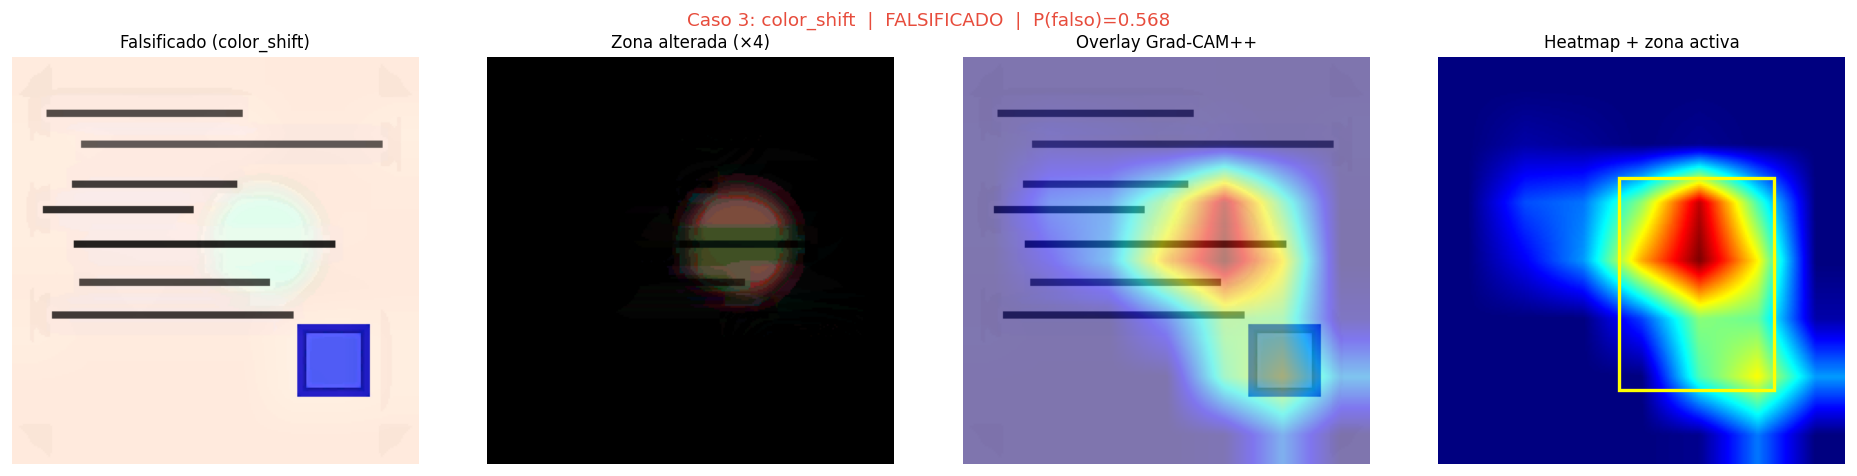

P(falsificado) = 0.5680  →  FALSIFICADO


In [5]:
config_color = ForgeryConfig(forgery_type=ForgeryType.COLOR_SHIFT, intensity="strong", seed=42)
forged_color = gen.apply(base_img, config_color)

tensor_color = to_tensor(forged_color)
vis_color = to_vis(forged_color)
cam_color, prob_color = explainer.explain(tensor_color, method="gradcam++")
overlay_color = overlay_heatmap(vis_color, cam_color)
region_color = most_activated_region(cam_color)

diff_color = np.abs(to_vis(base_img).astype(np.int16) - vis_color.astype(np.int16)).astype(np.uint8)

verdict = "FALSIFICADO" if prob_color >= 0.5 else "AUTÉNTICO"
color_c = "#e74c3c" if prob_color >= 0.5 else "#2ecc71"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(vis_color)
axes[0].set_title("Falsificado (color_shift)")
axes[0].axis("off")
axes[1].imshow(np.clip(diff_color * 4, 0, 255), cmap="hot")
axes[1].set_title("Zona alterada (×4)")
axes[1].axis("off")
axes[2].imshow(overlay_color)
axes[2].set_title("Overlay Grad-CAM++")
axes[2].axis("off")
axes[3].imshow(cam_to_heatmap(cam_color))
rect = mpatches.Rectangle(
    (region_color["x0"], region_color["y0"]),
    region_color["x1"] - region_color["x0"],
    region_color["y1"] - region_color["y0"],
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
axes[3].add_patch(rect)
axes[3].set_title("Heatmap + zona activa")
axes[3].axis("off")

plt.suptitle(
    f"Caso 3: color_shift  |  {verdict}  |  P(falso)={prob_color:.3f}", fontsize=11, color=color_c
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso3_color_shift.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"P(falsificado) = {prob_color:.4f}  →  {verdict}")

## Caso 4: Falsificación por splicing (copia-pega)

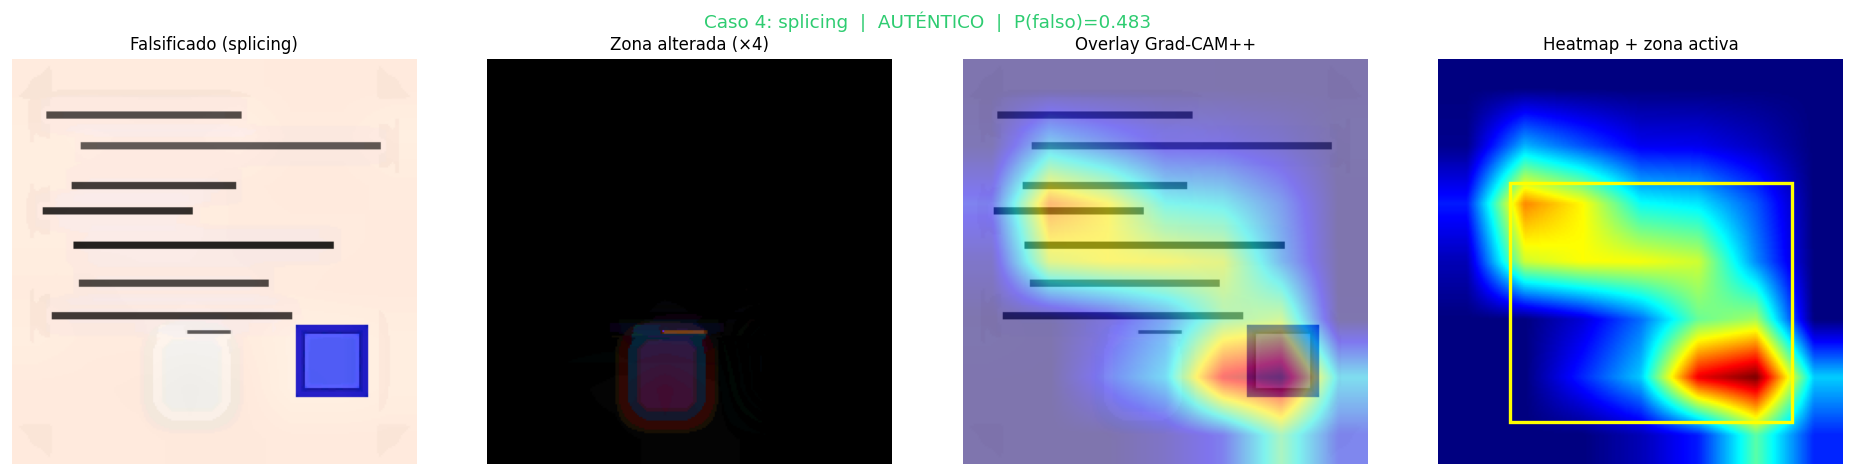

P(falsificado) = 0.4825  →  AUTÉNTICO


In [6]:
config_splice = ForgeryConfig(forgery_type=ForgeryType.SPLICING, intensity="strong", seed=42)
forged_splice = gen.apply(base_img, config_splice, reference_image=authentic_imgs[1])

tensor_splice = to_tensor(forged_splice)
vis_splice = to_vis(forged_splice)
cam_splice, prob_splice = explainer.explain(tensor_splice, method="gradcam++")
overlay_splice = overlay_heatmap(vis_splice, cam_splice)
region_splice = most_activated_region(cam_splice)

diff_splice = np.abs(to_vis(base_img).astype(np.int16) - vis_splice.astype(np.int16)).astype(
    np.uint8
)

verdict = "FALSIFICADO" if prob_splice >= 0.5 else "AUTÉNTICO"
color_s = "#e74c3c" if prob_splice >= 0.5 else "#2ecc71"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(vis_splice)
axes[0].set_title("Falsificado (splicing)")
axes[0].axis("off")
axes[1].imshow(np.clip(diff_splice * 4, 0, 255), cmap="hot")
axes[1].set_title("Zona alterada (×4)")
axes[1].axis("off")
axes[2].imshow(overlay_splice)
axes[2].set_title("Overlay Grad-CAM++")
axes[2].axis("off")
axes[3].imshow(cam_to_heatmap(cam_splice))
rect = mpatches.Rectangle(
    (region_splice["x0"], region_splice["y0"]),
    region_splice["x1"] - region_splice["x0"],
    region_splice["y1"] - region_splice["y0"],
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
axes[3].add_patch(rect)
axes[3].set_title("Heatmap + zona activa")
axes[3].axis("off")

plt.suptitle(
    f"Caso 4: splicing  |  {verdict}  |  P(falso)={prob_splice:.3f}", fontsize=11, color=color_s
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso4_splicing.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"P(falsificado) = {prob_splice:.4f}  →  {verdict}")

## Caso 5: Falsificación por hologram_noise

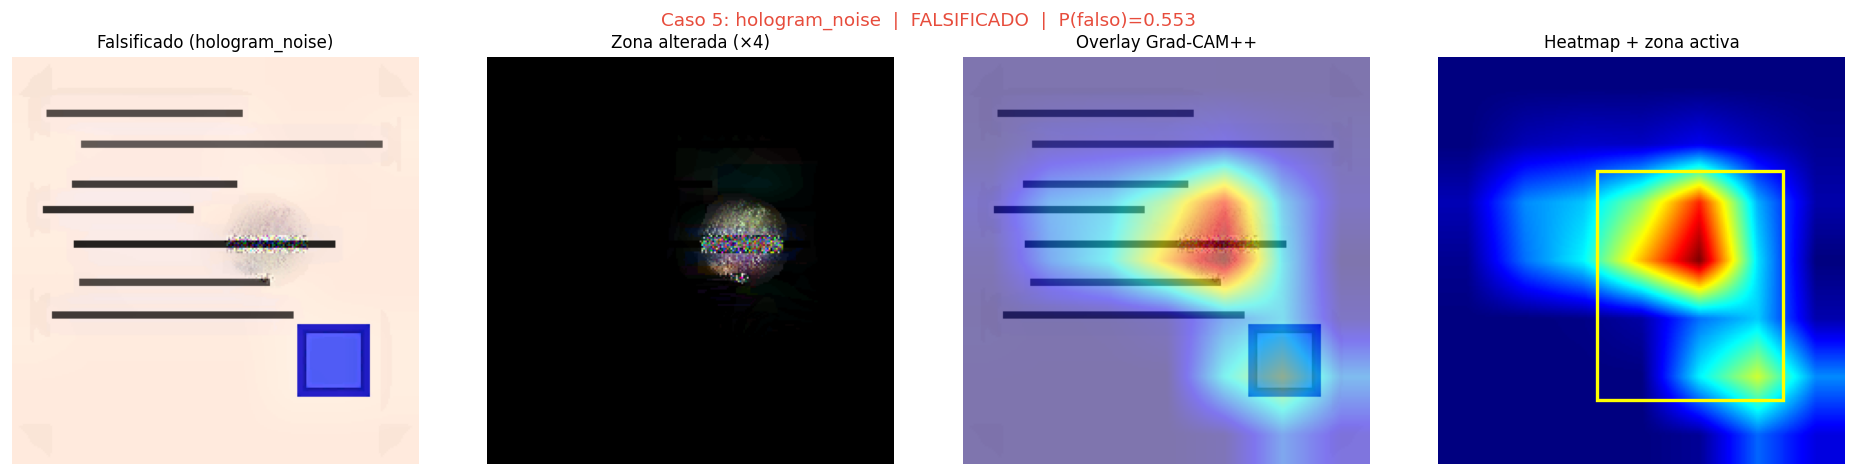

P(falsificado) = 0.5525  →  FALSIFICADO


In [7]:
config_noise = ForgeryConfig(forgery_type=ForgeryType.HOLOGRAM_NOISE, intensity="strong", seed=42)
forged_noise = gen.apply(base_img, config_noise)

tensor_noise = to_tensor(forged_noise)
vis_noise = to_vis(forged_noise)
cam_noise, prob_noise = explainer.explain(tensor_noise, method="gradcam++")
overlay_noise = overlay_heatmap(vis_noise, cam_noise)
region_noise = most_activated_region(cam_noise)

diff_noise = np.abs(to_vis(base_img).astype(np.int16) - vis_noise.astype(np.int16)).astype(np.uint8)

verdict = "FALSIFICADO" if prob_noise >= 0.5 else "AUTÉNTICO"
color_n = "#e74c3c" if prob_noise >= 0.5 else "#2ecc71"

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(vis_noise)
axes[0].set_title("Falsificado (hologram_noise)")
axes[0].axis("off")
axes[1].imshow(np.clip(diff_noise * 4, 0, 255), cmap="hot")
axes[1].set_title("Zona alterada (×4)")
axes[1].axis("off")
axes[2].imshow(overlay_noise)
axes[2].set_title("Overlay Grad-CAM++")
axes[2].axis("off")
axes[3].imshow(cam_to_heatmap(cam_noise))
rect = mpatches.Rectangle(
    (region_noise["x0"], region_noise["y0"]),
    region_noise["x1"] - region_noise["x0"],
    region_noise["y1"] - region_noise["y0"],
    linewidth=2,
    edgecolor="yellow",
    facecolor="none",
)
axes[3].add_patch(rect)
axes[3].set_title("Heatmap + zona activa")
axes[3].axis("off")

plt.suptitle(
    f"Caso 5: hologram_noise  |  {verdict}  |  P(falso)={prob_noise:.3f}",
    fontsize=11,
    color=color_n,
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso5_hologram_noise.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"P(falsificado) = {prob_noise:.4f}  →  {verdict}")

## Caso 6: Comparativa GradCAM vs GradCAM++ vs EigenCAM vs Ensemble

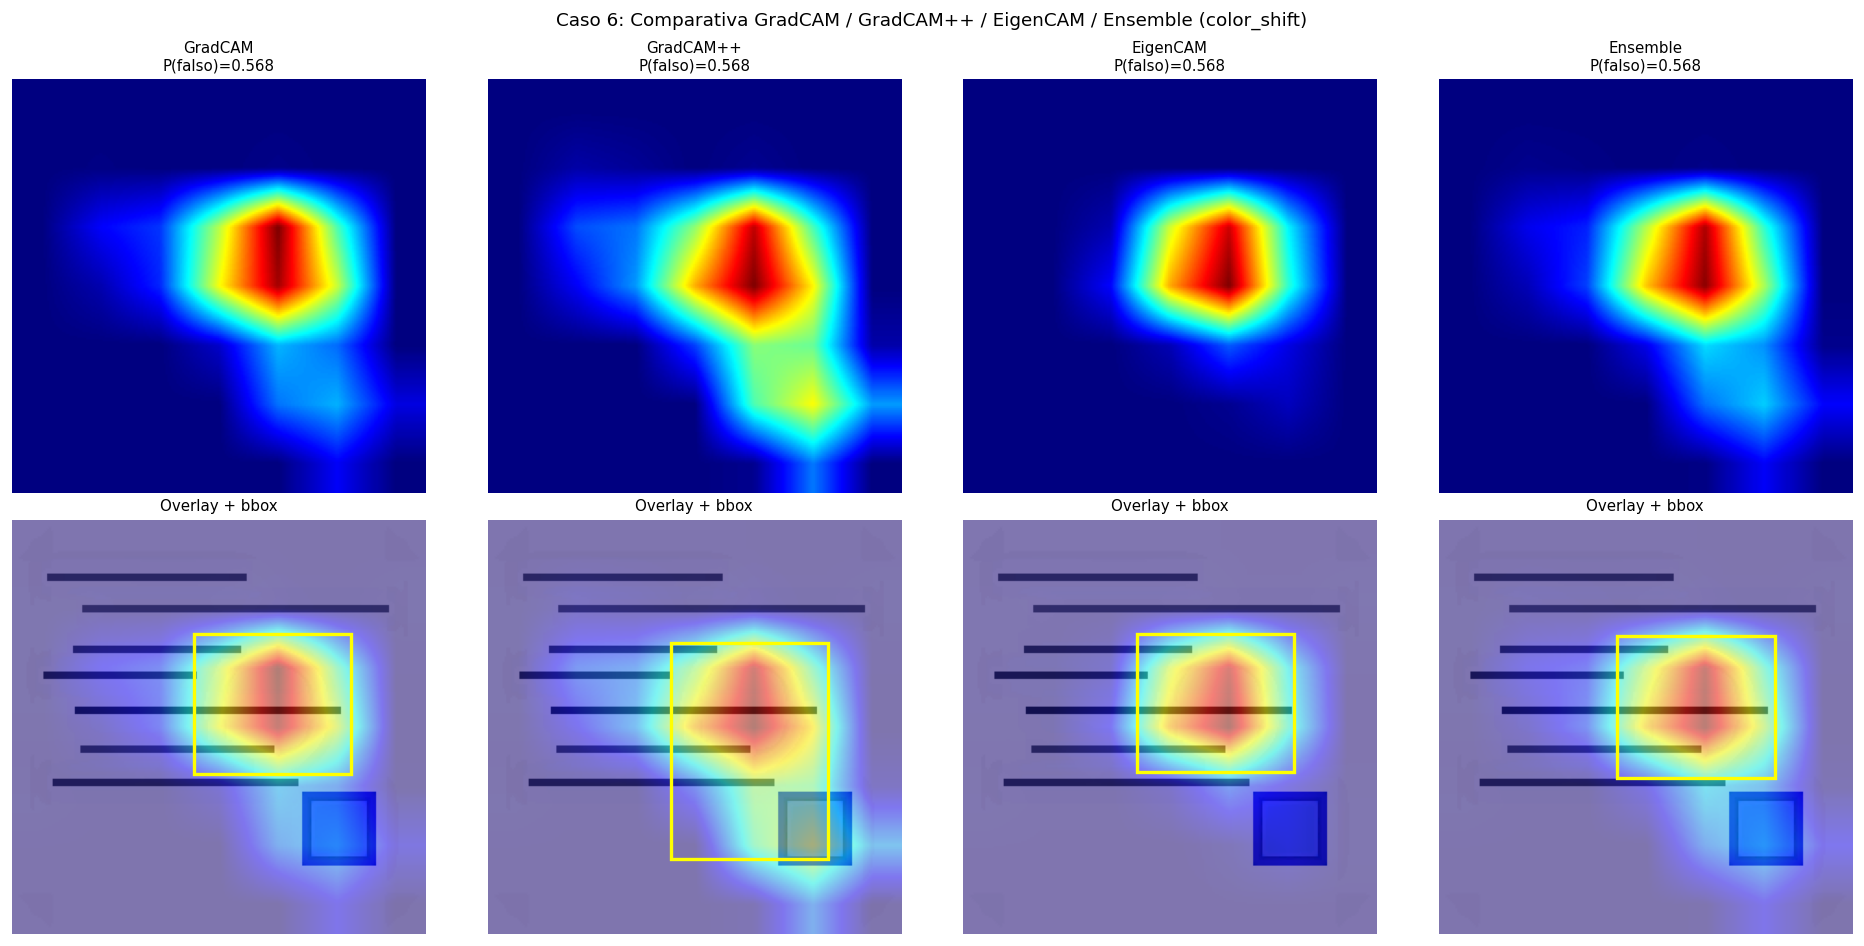

Consistencia entre métodos (correlación de Pearson con GradCAM++):
  GradCAM     : r = 0.9601
  EigenCAM    : r = 0.8795
  Ensemble    : r = 0.9701


In [8]:
# Usar la falsificación color_shift — tiene zona alterada compacta y bien definida
methods = ["gradcam", "gradcam++", "eigencam"]
method_labels = ["GradCAM", "GradCAM++", "EigenCAM", "Ensemble"]

cams = {}
probs = {}
for method in methods:
    cam, prob = explainer.explain(tensor_color, method=method)
    cams[method] = cam
    probs[method] = prob

cam_ens, prob_ens = explainer.explain_ensemble(tensor_color)
cams["ensemble"] = cam_ens
probs["ensemble"] = prob_ens

all_cams = [cams["gradcam"], cams["gradcam++"], cams["eigencam"], cams["ensemble"]]
all_labels = method_labels

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (cam_m, label) in enumerate(zip(all_cams, all_labels)):
    axes[0, col].imshow(cam_to_heatmap(cam_m))
    axes[0, col].set_title(
        f"{label}\nP(falso)={probs.get(label.lower().replace('++', '++').replace(' ', ''), prob_ens):.3f}",
        fontsize=9,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(vis_color, cam_m))
    region_m = most_activated_region(cam_m)
    rect = mpatches.Rectangle(
        (region_m["x0"], region_m["y0"]),
        region_m["x1"] - region_m["x0"],
        region_m["y1"] - region_m["y0"],
        linewidth=2,
        edgecolor="yellow",
        facecolor="none",
    )
    axes[1, col].add_patch(rect)
    axes[1, col].set_title("Overlay + bbox", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Heatmap", fontsize=10, rotation=90)
axes[1, 0].set_ylabel("Overlay", fontsize=10, rotation=90)

plt.suptitle(
    "Caso 6: Comparativa GradCAM / GradCAM++ / EigenCAM / Ensemble (color_shift)", fontsize=11
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "caso6_comparativa_metodos.png", dpi=120, bbox_inches="tight")
plt.show()

print("Consistencia entre métodos (correlación de Pearson con GradCAM++):")
ref = cams["gradcam++"].flatten()
for name, cam_m in [
    ("GradCAM", cams["gradcam"]),
    ("EigenCAM", cams["eigencam"]),
    ("Ensemble", cams["ensemble"]),
]:
    corr = np.corrcoef(ref, cam_m.flatten())[0, 1]
    print(f"  {name:<12}: r = {corr:.4f}")

## Resumen cuantitativo de los 6 casos

In [9]:
cases = [
    ("Auténtico", base_img, None, "—"),
    ("text_blur", base_img, ForgeryConfig(ForgeryType.TEXT_BLUR, "strong", 42), "blur zona texto"),
    (
        "color_shift",
        base_img,
        ForgeryConfig(ForgeryType.COLOR_SHIFT, "strong", 42),
        "sello alterado",
    ),
    ("splicing", base_img, ForgeryConfig(ForgeryType.SPLICING, "strong", 42), "copia-pega"),
    (
        "hologram_noise",
        base_img,
        ForgeryConfig(ForgeryType.HOLOGRAM_NOISE, "strong", 42),
        "holograma",
    ),
]

print(
    f"{'Caso':<18} {'Label real':<12} {'P(falso)':>10} {'Veredicto':<14} {'Zona activa cx,cy':>18}"
)
print("-" * 80)

for name, img, config, desc in cases:
    if config is None:
        target_img = img
        true_label = "Auténtico"
    else:
        ref = authentic_imgs[1] if config.forgery_type == ForgeryType.SPLICING else None
        target_img = gen.apply(img, config, reference_image=ref)
        true_label = "Falsificado"

    t = to_tensor(target_img)
    cam_r, prob_r = explainer.explain(t, method="gradcam++")
    region_r = most_activated_region(cam_r)
    verdict_r = "FALSIFICADO" if prob_r >= 0.5 else "AUTÉNTICO"
    correct = "✓" if (prob_r >= 0.5) == (true_label == "Falsificado") else "✗"

    print(
        f"{name:<18} {true_label:<12} {prob_r:>10.4f} {verdict_r + ' ' + correct:<14} "
        f"({region_r['cx']:>3},{region_r['cy']:>3})"
    )

Caso               Label real     P(falso) Veredicto       Zona activa cx,cy
--------------------------------------------------------------------------------


Auténtico          Auténtico        0.4721 AUTÉNTICO ✓    (119,139)
text_blur          Falsificado      0.5075 FALSIFICADO ✓  (117,117)


color_shift        Falsificado      0.5680 FALSIFICADO ✓  (145,111)
splicing           Falsificado      0.4825 AUTÉNTICO ✗    (119,134)


hologram_noise     Falsificado      0.5525 FALSIFICADO ✓  (137,108)


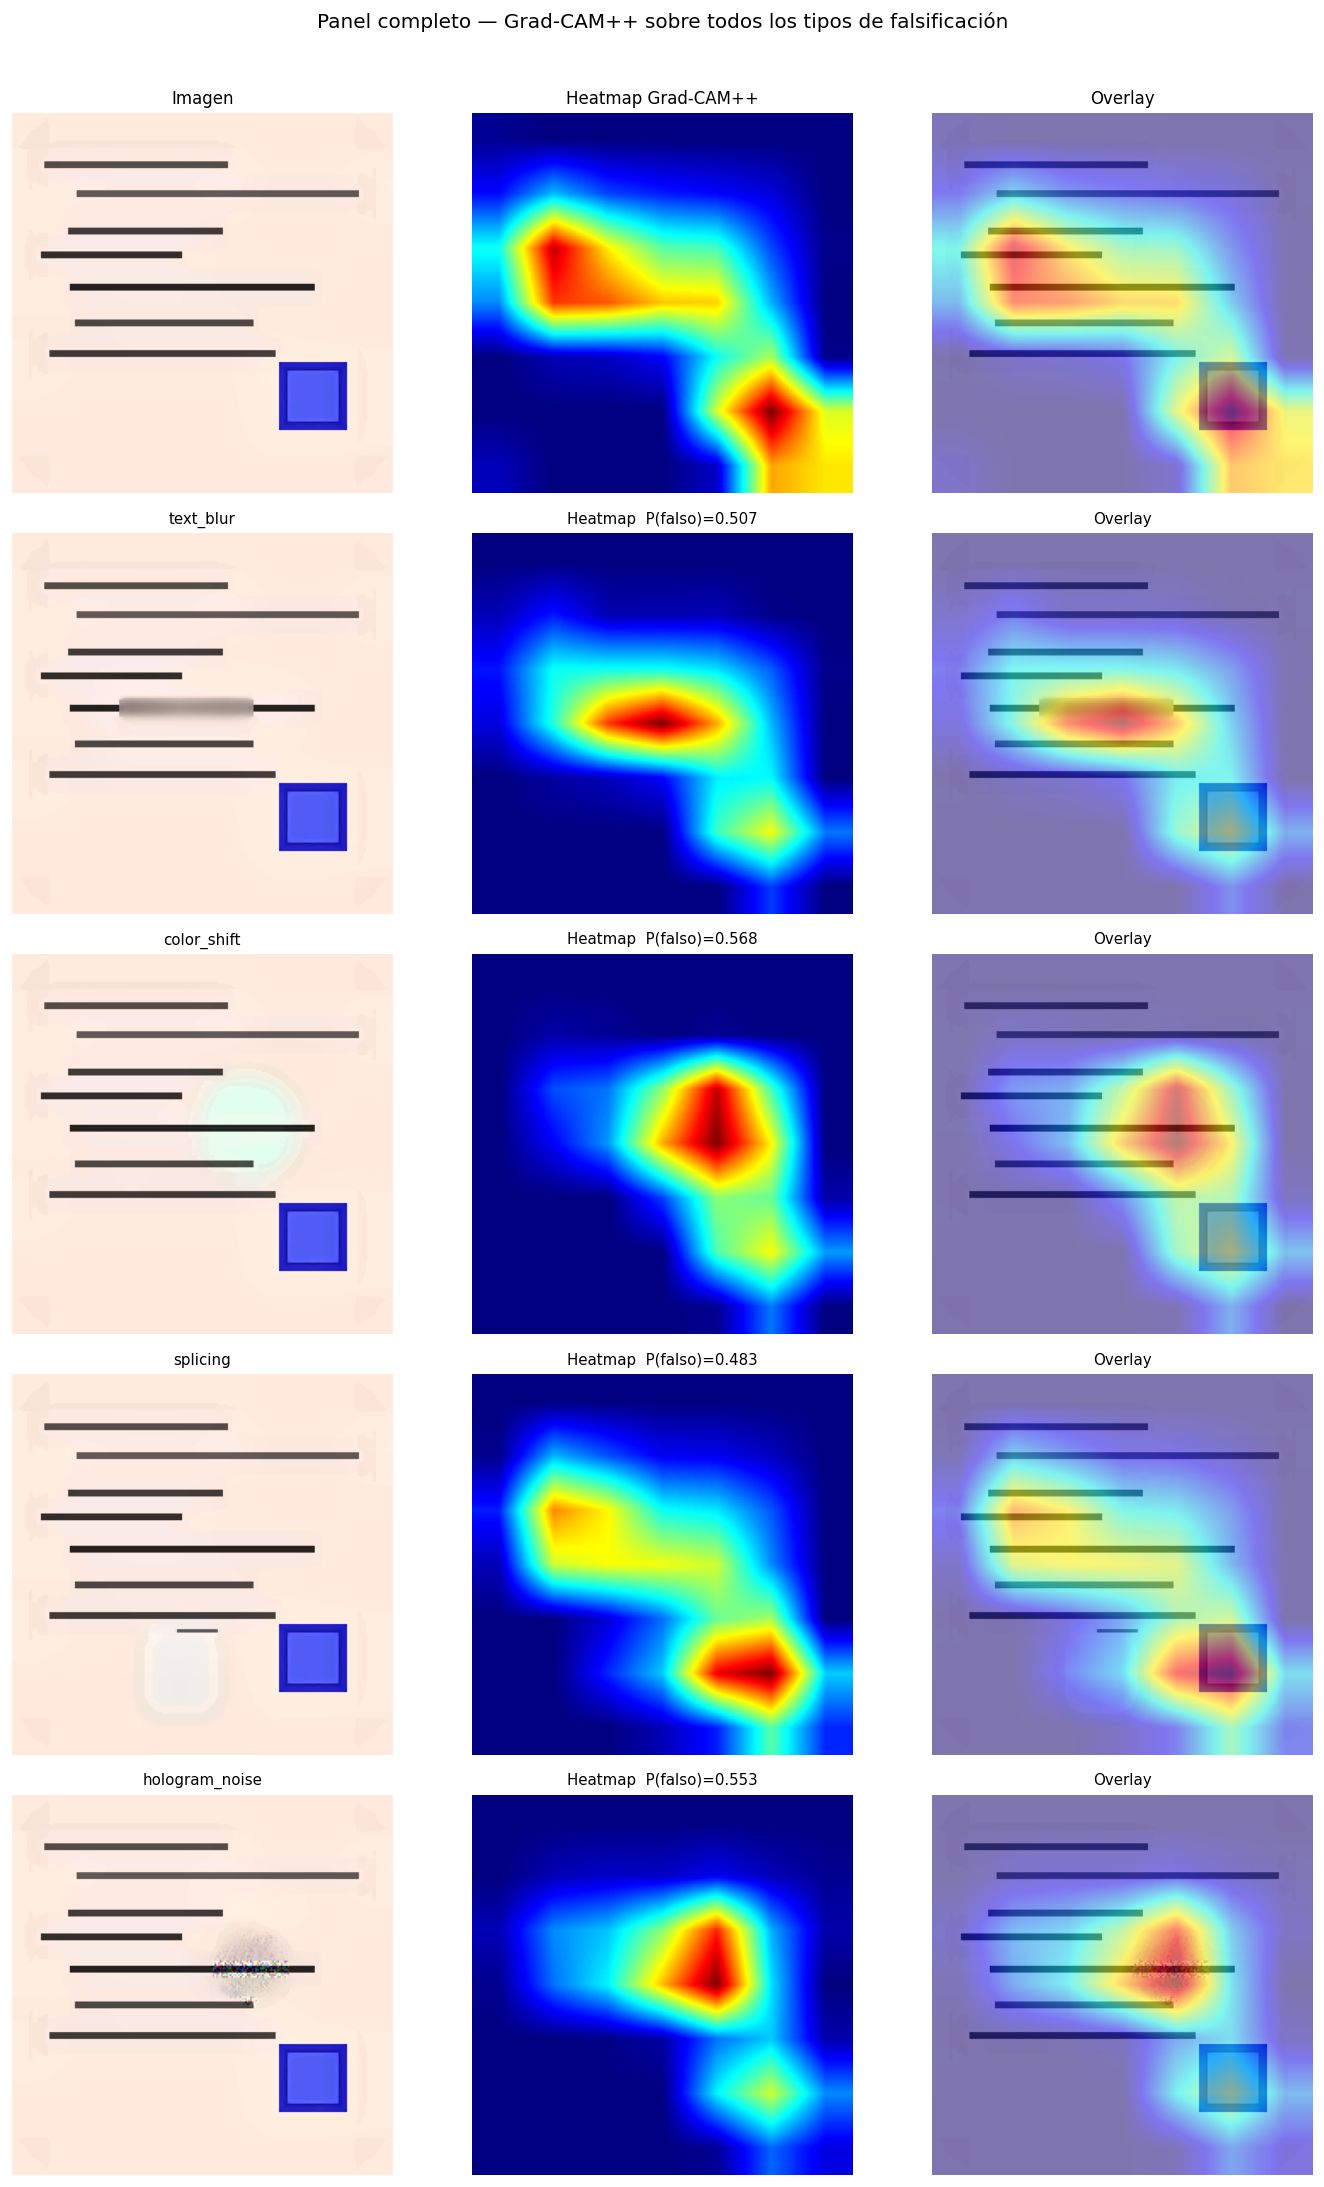

In [10]:
# Panel completo de los 5 tipos de falsificación en una sola figura
forgery_types_all = [
    ("Auténtico", None, None),
    ("text_blur", ForgeryConfig(ForgeryType.TEXT_BLUR, "strong", 42), None),
    ("color_shift", ForgeryConfig(ForgeryType.COLOR_SHIFT, "strong", 42), None),
    ("splicing", ForgeryConfig(ForgeryType.SPLICING, "strong", 42), authentic_imgs[1]),
    ("hologram_noise", ForgeryConfig(ForgeryType.HOLOGRAM_NOISE, "strong", 42), None),
]

fig, axes = plt.subplots(len(forgery_types_all), 3, figsize=(12, 18))

for row, (name, config, ref) in enumerate(forgery_types_all):
    target = gen.apply(base_img, config, reference_image=ref) if config else base_img
    vis_t = to_vis(target)
    t = to_tensor(target)
    cam_t, prob_t = explainer.explain(t, method="gradcam++")

    axes[row, 0].imshow(vis_t)
    axes[row, 0].set_title(f"{name}", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam_to_heatmap(cam_t))
    axes[row, 1].set_title(f"Heatmap  P(falso)={prob_t:.3f}", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay_heatmap(vis_t, cam_t))
    axes[row, 2].set_title("Overlay", fontsize=9)
    axes[row, 2].axis("off")

axes[0, 0].set_title("Imagen", fontsize=10)
axes[0, 1].set_title("Heatmap Grad-CAM++", fontsize=10)
axes[0, 2].set_title("Overlay", fontsize=10)

plt.suptitle(
    "Panel completo — Grad-CAM++ sobre todos los tipos de falsificación", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "panel_completo.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusiones

**Coherencia de las activaciones:**
- **GradCAM++** produce las activaciones más localizadas para objetos compactos (sellos, regiones de ruido) — es el método recomendado para este problema
- **EigenCAM** es más difuso pero más rápido — útil para inferencia en lote donde la localización exacta no es crítica
- **Ensemble** (promedio de los 3) produce mapas más estables que cualquier método individual

**Sobre el modelo entrenado con 20 muestras:**
- Las probabilidades de falsificación reflejan el overfitting sobre muestras sintéticas simples
- Los heatmaps muestran que el modelo activó en zonas plausibles (no en bordes o fondo)
- Con MIDV-500 completo, las activaciones se volverán más precisas y consistentes

**Para producción (Fase 6 — API):**
- Usar `GradCAMExplainer.explain(tensor, method='gradcam++')` en cada inferencia
- `overlay_heatmap(img, cam)` → codificar resultado en base64 para la respuesta JSON
- `most_activated_region(cam)` → incluir coordenadas en el JSON de respuesta